Add git location and imports

In [1]:
import os
print(os.getcwd())
import sys
sys.path.append('/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL')

/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main


In [44]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from itertools import product
import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from useful_functions import load_volume, mse, show, normalize, visualize_feature_channel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### **registration**

find image pairs for registration (for test)

In [26]:
# fsm pairs

with open('test_files.txt', 'r') as f:
    fsm_files = [line.strip() for line in f if line.strip()]
pairs = [(moving, fixed) for moving, fixed in product(fsm_files, fsm_files) if moving != fixed]

print(f"Found {len(fsm_files)} fsm files")
print(f"Found {len(pairs)} pairs.")

Found 8 fsm files
Found 56 pairs.


Run registration (run test)

In [6]:
type = "0050_base_cyc_norm_2b_mse" # change model (base/bottleneck/attetnion)
model_path ="/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/MSE_norm_models/0050_base_cyc_norm_2b_mse.pt" # change model path

output_dir = f"data/{type}/warped_results"
output_dir_path = Path(output_dir)

output_dir_path.mkdir(parents=True, exist_ok=True)

# results = []
 
for j, (moving_file, fixed_file) in enumerate(pairs, start=1):
    moving_path = Path(moving_file) 
    fixed_path = Path(fixed_file)

    moving_name = moving_path.stem
    fixed_name = fixed_path.stem

    output_dir_path = Path(output_dir)

    output_file = output_dir_path / f"warped_{moving_name}_{fixed_name}.npz"

    %run -i ../scripts/register.py --moving {fixed_file} --fixed {moving_file} --moved {output_file} --model {model_path} --gpu 0

    # results.append((moving_file, fixed_file, output_file))


Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123623.npy, with shape (1, 64, 8, 8, 8)
Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123625.npy, with shape (1, 64, 8, 8, 8)


Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123627.npy, with shape (1, 64, 8, 8, 8)
Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123629.npy, with shape (1, 64, 8, 8, 8)
Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123631.npy, with shape (1, 64, 8, 8, 8)
Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123633.npy, with shape (1, 64, 8, 8, 8)
Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123634.npy, with shape (1, 64, 8, 8, 8)
Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123636.npy, with shape (1, 64, 8, 8, 8)
Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123638.npy, with shape (1, 64, 8, 8, 8)
Bottleneck features saved to ..\data/outputs_attention/bottleneck_features_20250815_123640.npy, with shape (1, 64, 8, 8, 8)
Bottlene

Calculate MSE

In [27]:
types = ["0025_base_SSIM", "base_25_epochs", "0025_bott_skip_CycLr", "0030_ssim_mse_cyc_attention"]

mse_results_after = {}

for type_name in types:
    warped_dir = Path(f"/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/data_wraped/{type_name}/warped_results")
    warped_files = sorted(warped_dir.glob("warped_*.npz"))

    mse_after_list = []

    for (fixed_file, moving_file), warped_file in zip(pairs, warped_files):
        fixed_vol = load_volume(fixed_file)
        moving_vol = load_volume(moving_file)
        warped_vol = load_volume(warped_file)

        err_after = mse(fixed_vol, moving_vol, warped_vol, name = type_name)
        mse_after_list.append(err_after)

    mse_results_after[type_name] = np.mean(mse_after_list)


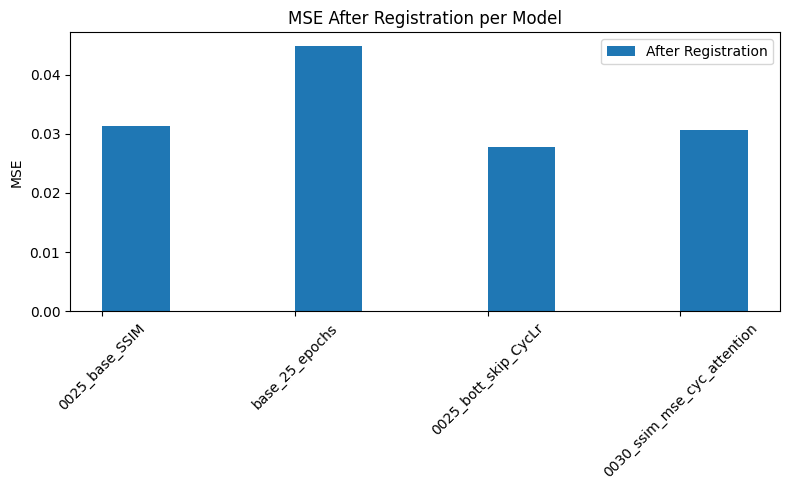

In [28]:
# plot mse on test images
labels = list(mse_results_after.keys())
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x + width/2, mse_results_after.values(), width, label='After Registration')

ax.set_ylabel('MSE')
ax.set_title('MSE After Registration per Model')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Exctract Feature Map

each method provide a different feature map in the most informative area

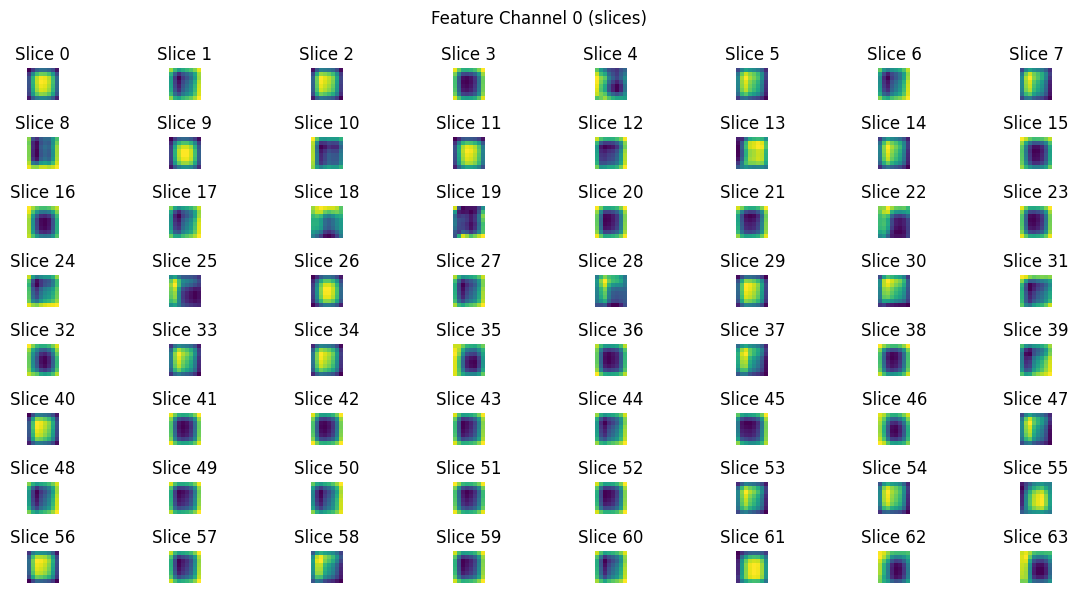

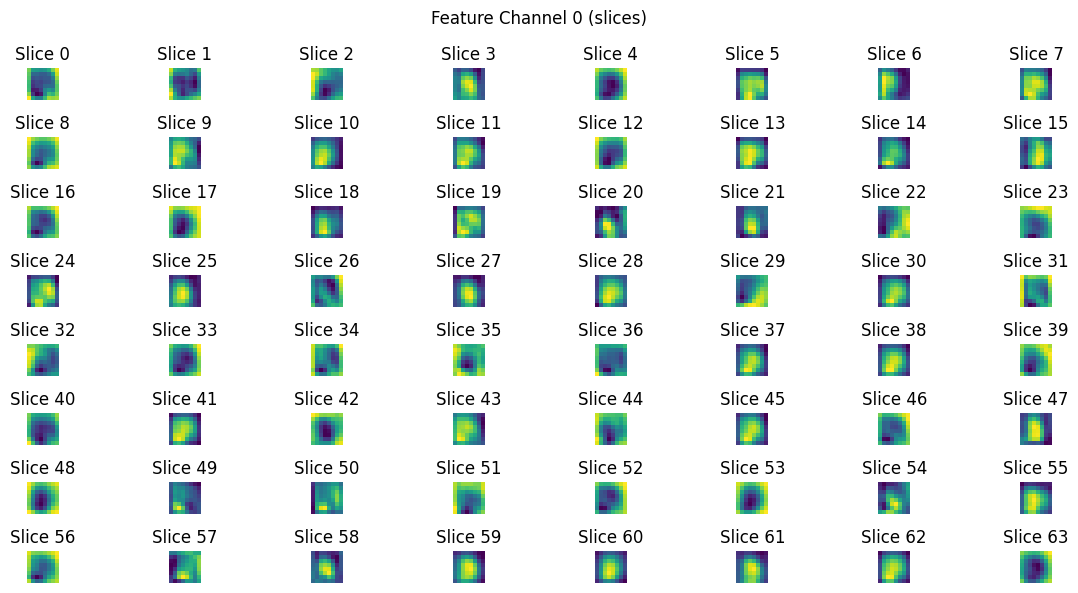

In [10]:
features_ssim_attention = np.load("/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/..\data/outputs_0030_ssim_mse_cyc_attention/bottleneck_features_20250815_004357.npy")  
features_base = np.load("/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/..\data/outputs_base/bottleneck_features_20250812_212603.npy")
visualize_feature_channel(features_ssim_attention, channel_index=0)
visualize_feature_channel(features_base, channel_index=0)

rearange the feature map

In [34]:
folder_path = '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/..\data/outputs_0050_base_cyc_norm_2b_mse'  # Replace with your actual folder path

# List all .npy files and sort them
files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
files.sort()

features_list = []
for file in files:
    file_path = os.path.join(folder_path, file)
    features = np.load(file_path)
    features_list.append(features)

# Stack into a numpy array (num_files, channels, D, H, W)
features_array = np.stack(features_list)

print('Aggregated features array shape:', features_array.shape)

Aggregated features array shape: (56, 1, 64, 8, 8, 8)


#### PCA

In [35]:
num_samples = features_array.shape[0]

# Flatten the features
features_flat = features_array.reshape(num_samples, -1)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_flat)

# Apply PCA
pca = PCA(n_components=10)
pca_result = pca.fit_transform(features_scaled)

explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio of first 10 components:", explained_variance)

Explained variance ratio of first 10 components: [0.32621112 0.16116238 0.11618964 0.0797032  0.05513664 0.0465829
 0.04033246 0.02523522 0.01584356 0.01150921]


K-means

Number of clusters found: 2
Sample cluster labels: [0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0]


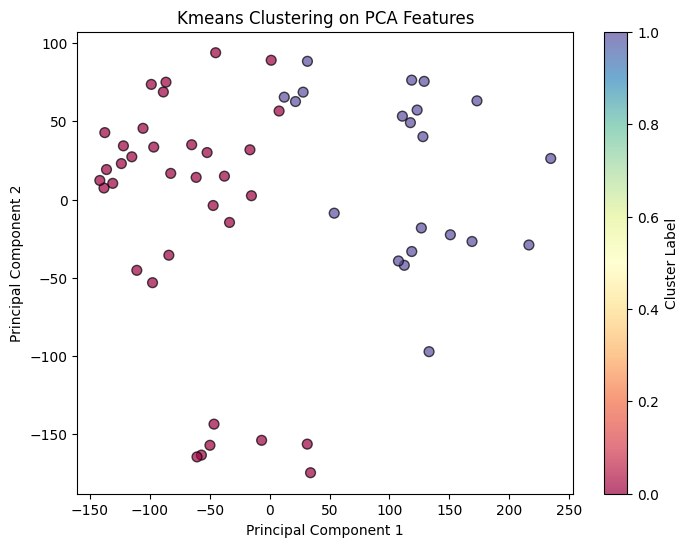

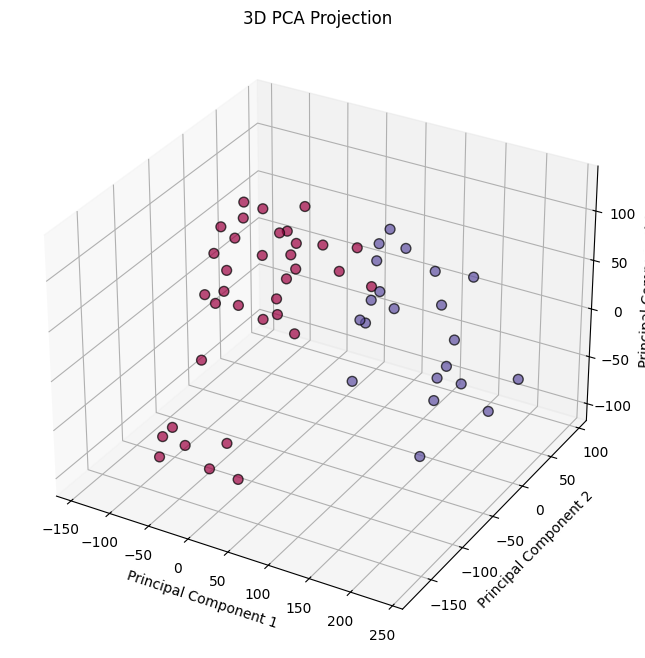

In [36]:
import hdbscan
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

n_clusters = 2  

kmeans = KMeans(
    n_clusters=n_clusters,
    init='k-means++',  
    n_init=10,  
    max_iter=300,  
    random_state=42  
)
cluster_labels = kmeans.fit_predict(pca_result)

num_clusters = len(set(cluster_labels))
print(f"Number of clusters found: {num_clusters}")

print("Sample cluster labels:", cluster_labels[:20])

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap='Spectral', s=50, alpha=0.7, edgecolors='k')
plt.colorbar(label='Cluster Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Kmeans Clustering on PCA Features')
plt.show()


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2], c=cluster_labels, cmap='Spectral', s=50, alpha=0.7, edgecolors='k')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Projection')
plt.show()




In [37]:
pink_indices = np.where(cluster_labels == 0)[0]
purple_indices = np.where(cluster_labels == 1)[0]
print(f"shape pink: {pink_indices.shape} | shape purple: {purple_indices.shape}")

pairs = np.array(pairs) 
pink_pairs = pairs[pink_indices]
purple_pairs = pairs[purple_indices]

pink_example = pink_pairs[0]   # First pair from pink cluster
purple_example = purple_pairs[0]  # First pair from purple cluster

shape pink: (35,) | shape purple: (21,)


In [43]:
print(pink_pairs[10])
print(purple_pairs[10])

['../../converted_npz_new_3D/normalized/fsm_t1_10cv.npz'
 '../../converted_npz_new_3D/normalized/fsm_t1_79bf.npz']
['../../converted_npz_new_3D/normalized/fsm_t1_79bf.npz'
 '../../converted_npz_new_3D/normalized/fsm_t1_30gy.npz']


These is actually a classifier beween inverse transformation!

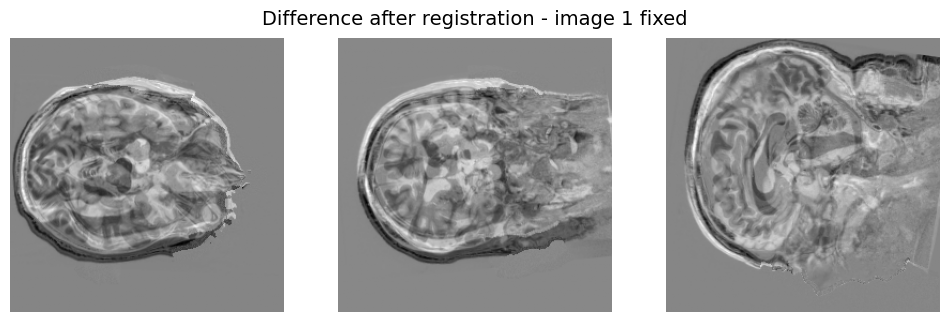

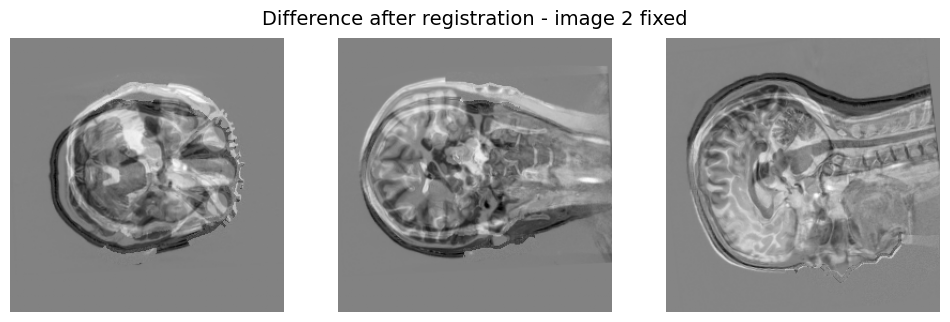

In [40]:
# 2 pairs - pink and purpule 

moving = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz_new_3D/fsm_t1_90ao.npz')
fixed = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz_new_3D/fsm_t1_96ry.npz')
warped_img1_img2 = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/data_wraped/0030_baseline_no_cyc_mse/warped_results/warped_fsm_t1_90ao_fsm_t1_96ry.npz')
warped_img1_img2 = warped_img1_img2.transpose(2, 1, 0)
warped_img2_img1 = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/data_wraped/0030_baseline_no_cyc_mse/warped_results/warped_fsm_t1_96ry_fsm_t1_90ao.npz')
warped_img2_img1 = warped_img2_img1.transpose(2, 1, 0)
after_img1_fixed = normalize(warped_img1_img2) - normalize(fixed)
after_img2_fixed = normalize(warped_img2_img1) - normalize(moving)

show(after_img1_fixed, title='Difference after registration - image 1 fixed')
show(after_img2_fixed, title='Difference after registration - image 2 fixed')


# Visualize Results

Show results registration

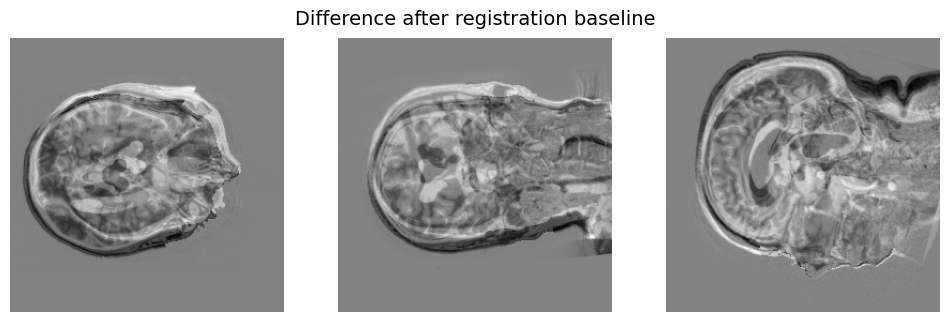

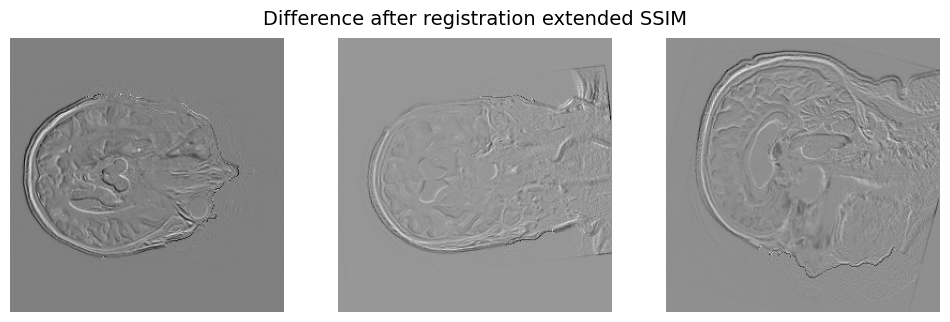

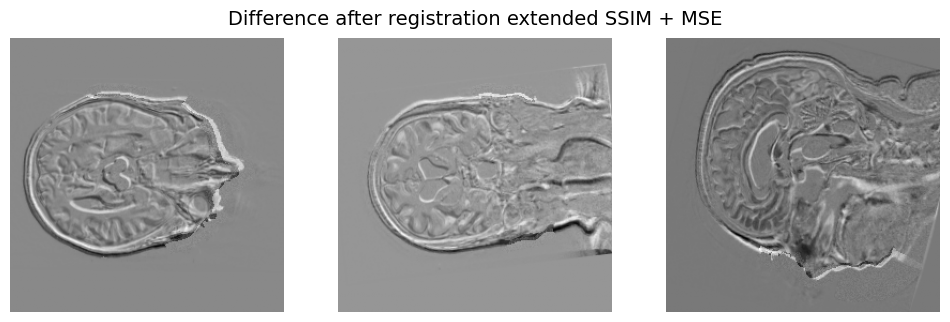

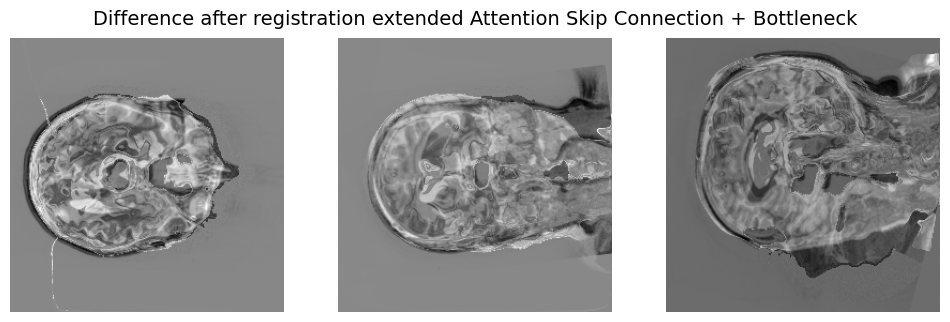

In [24]:
moving = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz_new_3D/fsm_t1_10cv.npz')
fixed = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz_new_3D/fsm_t1_79bf.npz')
warped = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/data_wraped/0030_baseline_no_cyc_mse/warped_results/warped_fsm_t1_10cv_fsm_t1_79bf.npz')
warped = warped.transpose(2, 1, 0)
warped_after_correction_base_SSIM_mse = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/data_wraped/0030_ssim_mse_cyc_attention/warped_results/warped_fsm_t1_10cv_fsm_t1_79bf.npz')
warped_after_correction_base_SSIM_mse = warped_after_correction_base_SSIM_mse.transpose(2, 1, 0)
warped_after_correction_base_SSIM = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/data_wraped/0025_base_SSIM/warped_results/warped_fsm_t1_10cv_fsm_t1_79bf.npz')
warped_after_correction_base_SSIM = warped_after_correction_base_SSIM.transpose(2, 1, 0)
warped_after_correction_attention = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/Data_warped_and_bottleneck/data_wraped/0025_bott_skip_CycLr/warped_results/warped_fsm_t1_10cv_fsm_t1_79bf.npz')
# warped_fixed_axes = warped.transpose(2, 1, 0)

after = normalize(warped) - normalize(fixed)
after_corr = warped_after_correction_base_SSIM - normalize(fixed)
after_corr_ = warped_after_correction_base_SSIM_mse - normalize(fixed)
after_skip_attention = normalize(warped_after_correction_attention) - normalize(fixed)
show(after, title='Difference after registration baseline')
show(after_corr, title='Difference after registration extended SSIM')
show(after_corr_, title='Difference after registration extended SSIM + MSE')
show(after_skip_attention, title='Difference after registration extended Attention Skip Connection + Bottleneck')

